In [2]:
import torch
from torch import tensor
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
np_data = np.arange(6).reshape((2, 3))
torch_data = torch.from_numpy(np_data)
tensor2array = torch_data.numpy()
print(
    "\nnumpy array:", np_data,          # [[0 1 2], [3 4 5]]
    "\ntorch tensor:", torch_data,      # tensor([[0, 1, 2], [3, 4, 5]])
    "\ntensor to array:", tensor2array  # [[0 1 2], [3 4 5]]
)


numpy array: [[0 1 2]
 [3 4 5]] 
torch tensor: tensor([[0, 1, 2],
        [3, 4, 5]]) 
tensor to array: [[0 1 2]
 [3 4 5]]


In [4]:
data = [-1, -2, 1, 2]
tensor = torch.FloatTensor(data)

print(\
    '\nabs'
    '\nnumpy: ', np.sin(data),
    '\ntorch:', torch.sin(tensor)  )


abs
numpy:  [-0.84147098 -0.90929743  0.84147098  0.90929743] 
torch: tensor([-0.8415, -0.9093,  0.8415,  0.9093])


In [5]:
data = [[1,2], [3,4]]
tensor = torch.FloatTensor(data)

print(
    "\nmatrix nultiplication (matmul)",
    '\nnumpy:', np.matmul(data,data),
    '\ntorch:', torch.mm(tensor, tensor)
)


matrix nultiplication (matmul) 
numpy: [[ 7 10]
 [15 22]] 
torch: tensor([[ 7., 10.],
        [15., 22.]])


In [6]:
from PIL import Image
from torch.utils.data import dataset
import os

In [7]:
x = torch.unsqueeze(torch.linspace(-1, 1, 100), dim=1).requires_grad_(True)
y = x.pow(2) + 0.2 * torch.rand(x.size())

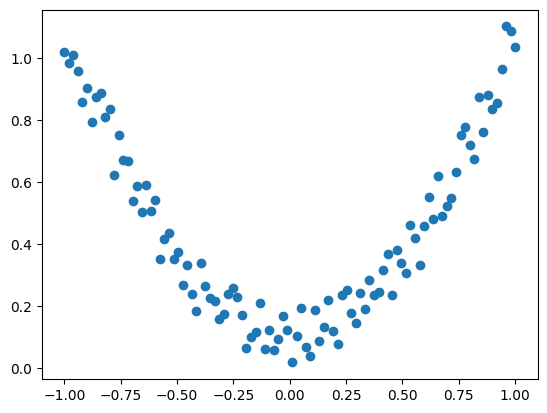

In [8]:
plt.scatter(x.data.numpy(), y.data.numpy())
plt.show()

In [9]:
class Net(torch.nn.Module):
    def __init__(self, n_features, n_hidden,n_output):
        super(Net,self).__init__()
        self.hidden = torch.nn.Linear(n_features, n_hidden)
        self.predict = torch.nn.Linear(n_hidden, n_output)
    def forward(self,x):
        x = F.relu(self.hidden(x))
        x = self.predict(x)
        return x
    
net = Net(1, 10, 1)
print(net) 

Net(
  (hidden): Linear(in_features=1, out_features=10, bias=True)
  (predict): Linear(in_features=10, out_features=1, bias=True)
)


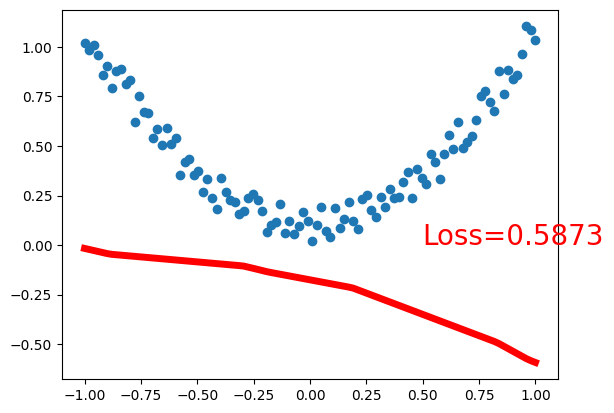

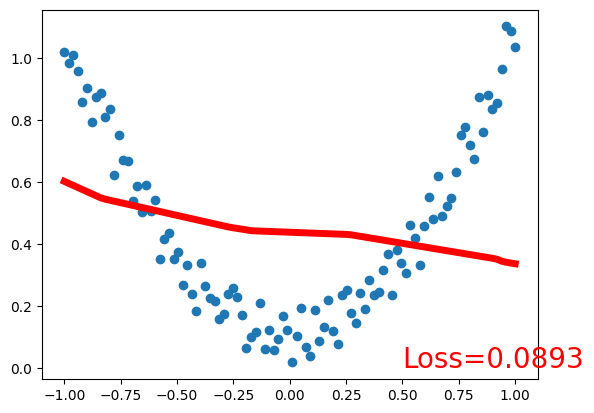

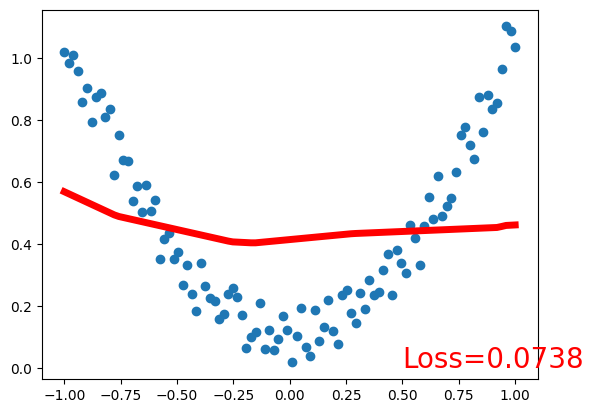

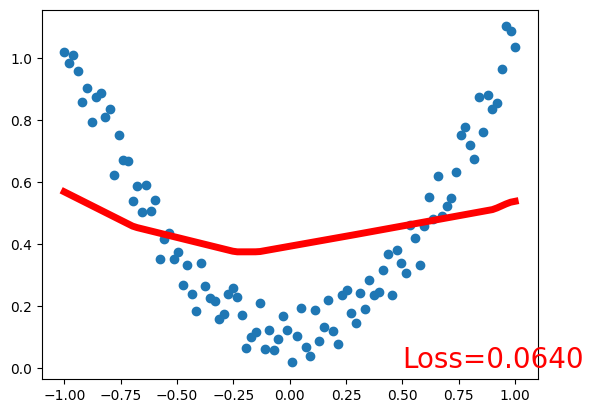

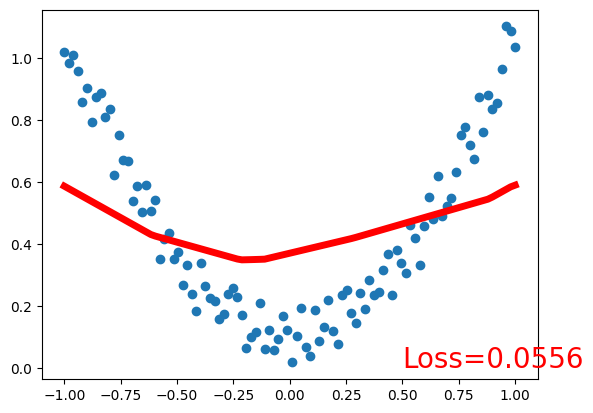

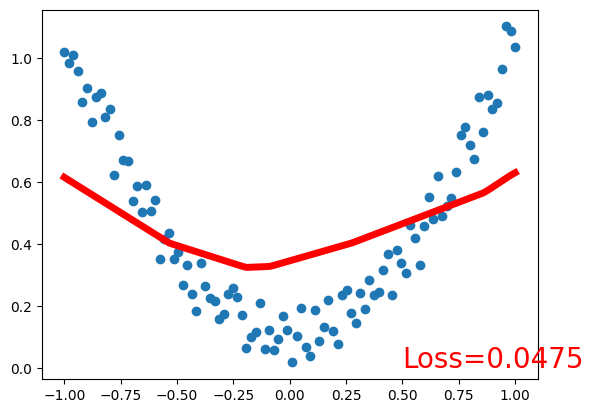

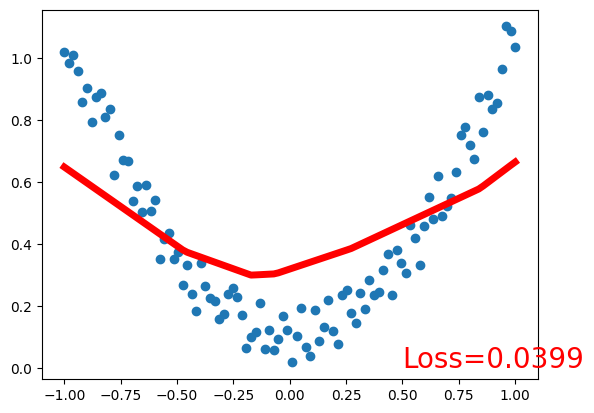

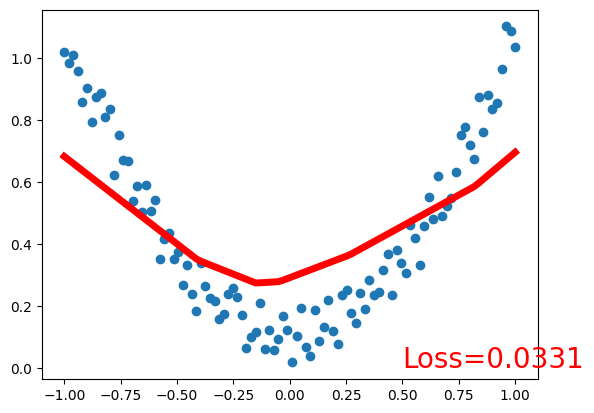

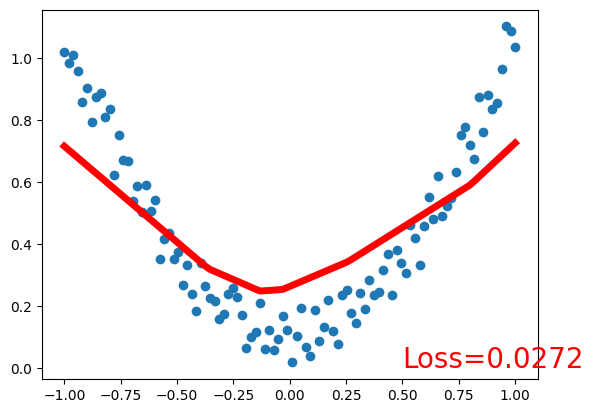

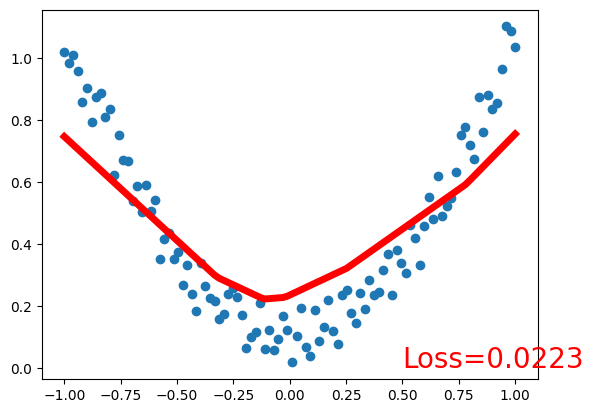

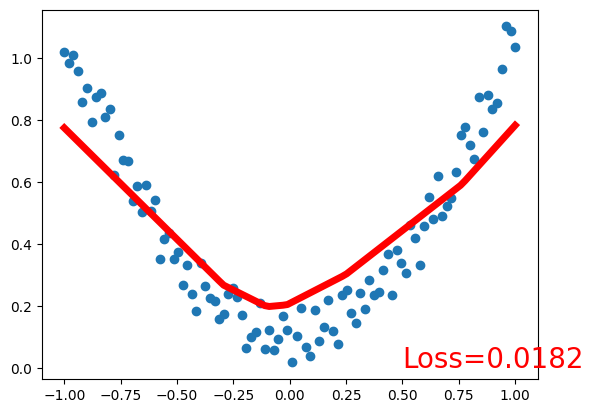

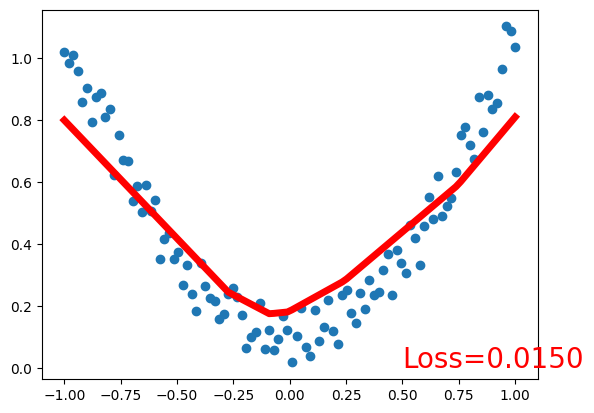

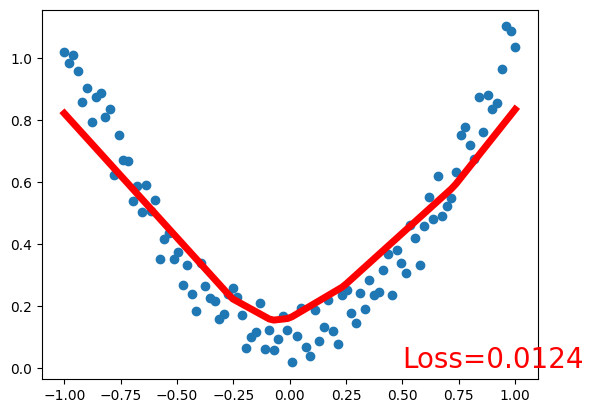

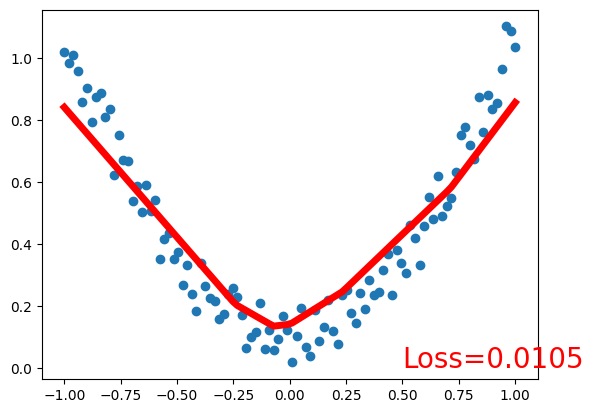

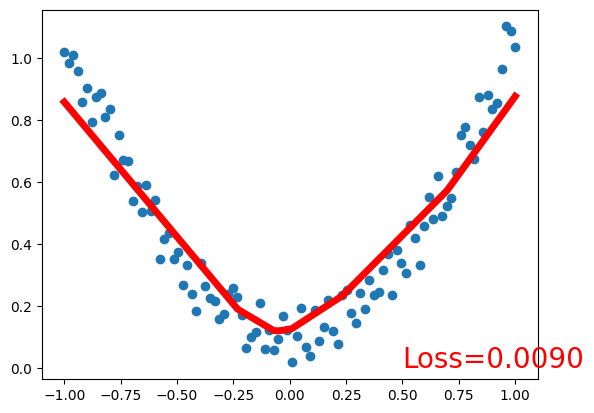

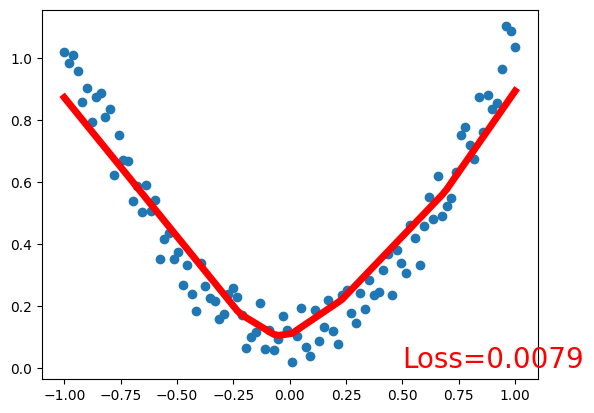

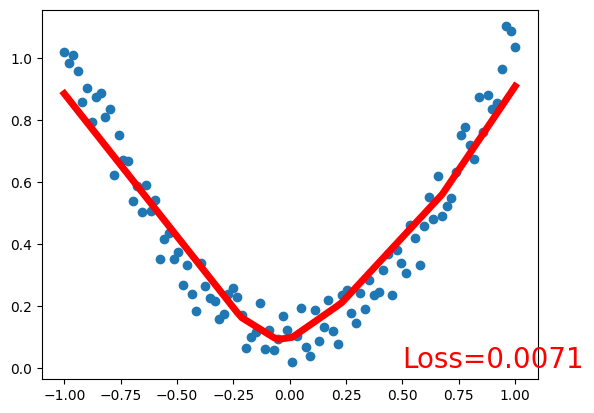

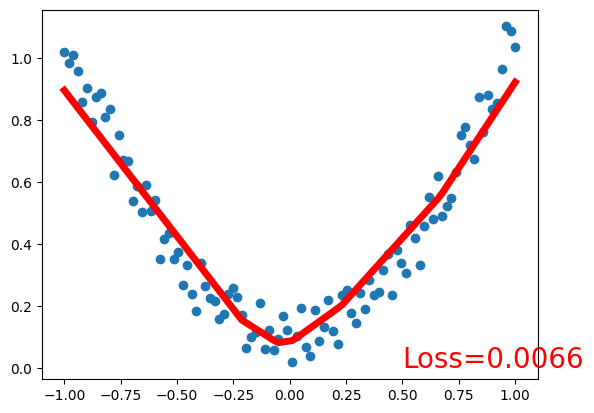

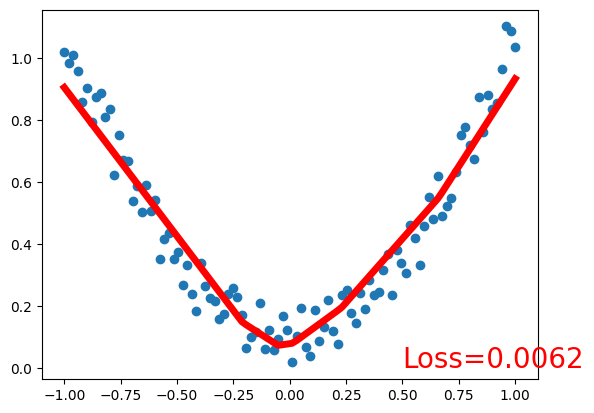

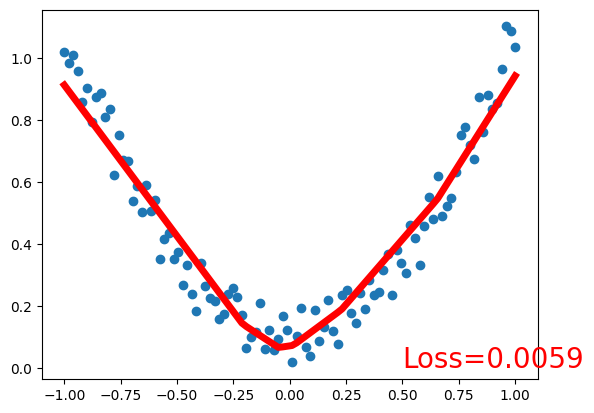

In [10]:
plt.ion()

optimizer = torch.optim.SGD(net.parameters(), lr=0.2)
loss_func = torch.nn.MSELoss()
for t in range(100):
    prediction = net(x)     # input x and predict based on x
    loss = loss_func(prediction, y)  # must be (1. nn output, 2. target)
    optimizer.zero_grad()   # clear gradients for next train
    loss.backward(retain_graph=True)         # backpropagation, compute gradients
    optimizer.step()        # apply gradients
    if t % 5 == 0:
        plt.cla()
        plt.scatter(x.data.numpy(), y.data.numpy())
        plt.plot(x.data.numpy(), prediction.detach().numpy(), 'r-', lw=5)
        plt.text(0.5, 0, f'Loss={loss.item():.4f}', fontdict={'size': 20, 'color': 'red'})
        plt.pause(0.1)
plt.ioff()
plt.show()